In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("priyankabarik/chronic-kidney-disease-ckd-clinical-dataset")

print("Path to dataset files:", path)

/Users/shubham/Desktop/ML_REPO/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/shubham/.cache/kagglehub/datasets/priyankabarik/chronic-kidney-disease-ckd-clinical-dataset/versions/1


In [177]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score,roc_auc_score,confusion_matrix

In [178]:
path = "/Users/shubham/.cache/kagglehub/datasets/priyankabarik/chronic-kidney-disease-ckd-clinical-dataset/versions/1"
train_file_name =  "Training_CKD_dataset.csv"
test_file_name = "Testing_CKD_dataset.csv"

os.listdir(path)

['Training_CKD_dataset.csv', 'Testing_CKD_dataset.csv', 'test_predictions.csv']

In [179]:
training_df = pd.read_csv(os.path.join(path, train_file_name))
testing_df = pd.read_csv(os.path.join(path, test_file_name))

In [180]:
training_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  str    
 1   Age                       21000 non-null  int64  
 2   Gender                    21000 non-null  int64  
 3   BMI                       21000 non-null  int64  
 4   Systolic_BP               21000 non-null  int64  
 5   Diastolic_BP              21000 non-null  int64  
 6   Heart_Rate                21000 non-null  int64  
 7   Serum_Creatinine          21000 non-null  int64  
 8   Blood_Urea_Nitrogen       21000 non-null  int64  
 9   eGFR                      21000 non-null  int64  
 10  Urine_Albumin             21000 non-null  int64  
 11  Urine_Protein             21000 non-null  int64  
 12  Albumin_Creatinine_Ratio  21000 non-null  int64  
 13  Urine_Specific_Gravity    21000 non-null  float64
 14  Sodium           

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Healthy Kidney'),
  Text(1, 0, 'Severe CKD (Stage 4)'),
  Text(2, 0, 'Mild CKD (Stage 1–2)'),
  Text(3, 0, 'Moderate CKD (Stage 3)'),
  Text(4, 0, 'Kidney Failure (Stage 5)')])

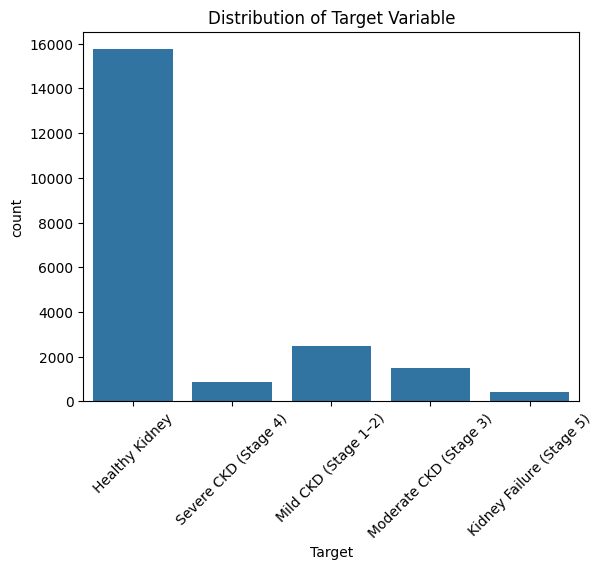

In [181]:
sns.countplot(x='Target', data=training_df)
plt.title('Distribution of Target Variable')
plt.xticks(rotation=45)

In [182]:
y = training_df['Target']
X = training_df.drop(columns=['Target'])

In [183]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20,random_state=42)

In [184]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [185]:
categirical_features = ["Gender","Diabetes",                  
                        "Hypertension",           
                        "Smoking_Status",           
                        "Family_History_Kidney"] 

numerical_features  = list(set(X.columns.to_list()) - set(categirical_features))

In [186]:
col_transformer_stages = [("Num_col",StandardScaler(),numerical_features),
                          ("Cat_col",OrdinalEncoder(),categirical_features)]

preprocessor = ColumnTransformer(transformers= col_transformer_stages)

In [187]:
model_pipeline = Pipeline(steps=[('pre_process',preprocessor),('rf',RandomForestClassifier())])

In [188]:
model_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre_process', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Num_col', ...), ('Cat_col', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [189]:
y_pred = model_pipeline.predict(X_train)
y_prob = model_pipeline.predict_proba(X_train)


print ("="*10,"Training","="*10)
print("ROC - AUC Score : " ,roc_auc_score(y_train,y_prob,multi_class='ovr'))
print("Classification Report : \n",classification_report(y_train,y_pred))

========== Training ==========
ROC - AUC Score :  1.0
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     12584
           1       1.00      1.00      1.00       327
           2       1.00      1.00      1.00      2003
           3       1.00      1.00      1.00      1184
           4       1.00      1.00      1.00       702

    accuracy                           1.00     16800
   macro avg       1.00      1.00      1.00     16800
weighted avg       1.00      1.00      1.00     16800



In [190]:
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)

print ("="*10,"Test","="*10)
print("ROC - AUC Score : " ,roc_auc_score(y_test,y_prob,multi_class='ovr'))
print("Classification Report : \n",classification_report(y_test,y_pred))

========== Test ==========
ROC - AUC Score :  1.0
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3160
           1       1.00      1.00      1.00        93
           2       1.00      1.00      1.00       488
           3       1.00      1.00      1.00       305
           4       1.00      1.00      1.00       154

    accuracy                           1.00      4200
   macro avg       1.00      1.00      1.00      4200
weighted avg       1.00      1.00      1.00      4200



In [191]:
print(confusion_matrix(y_test, y_pred))

[[3160    0    0    0    0]
 [   0   93    0    0    0]
 [   0    0  488    0    0]
 [   0    0    0  305    0]
 [   0    0    0    0  154]]


<b> Observations </b>:
- AUC is 1 that means the classes are perfectly saperable. : Sounds good
- Precision and Recall are also 1 that means no False positive and False Negative. : This can't be real, either data is synthetic
or cleaned.
- Accuracy and F1 Score are also 1. :  the precision and recall are well balanced and all the classes were predicted correctly


<b> Possibility </b>
- May be one ore more features are directly interpretable to the target.

In [192]:
rf_model = model_pipeline.named_steps["rf"]
importances = rf_model.feature_importances_
feature_names = model_pipeline.named_steps["pre_process"].get_feature_names_out()
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)
feature_importance_df.head(15)

,feature,importance
3,Num_col__Blood_Urea_Nitrogen,0.123446
2,Num_col__Serum_Creatinine,0.120645
13,Num_col__Urine_Protein,0.119950
18,Num_col__Albumin_Creatinine_Ratio,0.116938
26,Num_col__Urine_Albumin,0.101381
6,Num_col__eGFR,0.094143
15,Num_col__Diastolic_BP,0.088255
20,Num_col__Systolic_BP,0.082807
27,Num_col__Serum_Albumin,0.064577
23,Num_col__Hemoglobin,0.024054


In [193]:
features_to_be_removed = feature_importance_df.iloc[0:10,0].values
features_to_be_removed = [i.split('__')[-1] for i in features_to_be_removed] 
features_to_be_removed

['Blood_Urea_Nitrogen',
 'Serum_Creatinine',
 'Urine_Protein',
 'Albumin_Creatinine_Ratio',
 'Urine_Albumin',
 'eGFR',
 'Diastolic_BP',
 'Systolic_BP',
 'Serum_Albumin',
 'Hemoglobin']

In [199]:
training_df = pd.read_csv(os.path.join(path, train_file_name))


In [200]:
X = training_df.drop(columns=features_to_be_removed)
X = X.drop(columns=['Target'])
y = training_df['Target']


In [201]:

categirical_features = ["Gender","Diabetes",                  
                        "Hypertension",           
                        "Smoking_Status",           
                        "Family_History_Kidney"] 

numerical_features  = list(set(X.columns.to_list()) - set(categirical_features))

In [202]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=.2,random_state=42)

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [203]:
col_transformer_stages = [("Num_col",StandardScaler(),numerical_features),
                          ("Cat_col",OrdinalEncoder(),categirical_features)]

preprocessor = ColumnTransformer(transformers= col_transformer_stages)
model_pipeline = Pipeline(steps=[('pre_process',preprocessor),('rf',RandomForestClassifier())])

In [204]:
model_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre_process', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Num_col', ...), ('Cat_col', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [205]:
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)

print ("="*10,"Test","="*10)
print("ROC - AUC Score : " ,roc_auc_score(y_test,y_prob,multi_class='ovr'))
print("Classification Report : \n",classification_report(y_test,y_pred))

========== Test ==========
ROC - AUC Score :  0.9971046316900247
Classification Report : 
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     12601
           1       1.00      0.97      0.99       341
           2       0.96      0.88      0.92      1984
           3       0.97      0.92      0.95      1211
           4       0.96      0.95      0.96       663

    accuracy                           0.98     16800
   macro avg       0.98      0.95      0.96     16800
weighted avg       0.98      0.98      0.98     16800



In [206]:
y_pred = model_pipeline.predict(X_train)
y_prob = model_pipeline.predict_proba(X_train)


print ("="*10,"Training","="*10)
print("ROC - AUC Score : " ,roc_auc_score(y_train,y_prob,multi_class='ovr'))
print("Classification Report : \n",classification_report(y_train,y_pred))

========== Training ==========
ROC - AUC Score :  1.0
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3143
           1       1.00      1.00      1.00        79
           2       1.00      1.00      1.00       507
           3       1.00      1.00      1.00       278
           4       1.00      1.00      1.00       193

    accuracy                           1.00      4200
   macro avg       1.00      1.00      1.00      4200
weighted avg       1.00      1.00      1.00      4200



<b> The Model still has the overfitting, 
 - let's proceed with the predictions  on Test data provided

In [222]:
testing_df = pd.read_csv(os.path.join(path, test_file_name))
X = testing_df.drop(columns=features_to_be_removed)
X = X.drop(columns=['Target'])
y = testing_df['Target']
y = le.transform(y)


In [223]:
X.columns

Index(['Age', 'Gender', 'BMI', 'Heart_Rate', 'Urine_Specific_Gravity',
       'Sodium', 'Potassium', 'Calcium', 'Phosphorus', 'Chloride',
       'Bicarbonate', 'RBC_Count', 'WBC_Count', 'Platelet_Count',
       'Packed_Cell_Volume', 'Blood_Glucose_Random', 'Fasting_Glucose',
       'HbA1c', 'Cholesterol', 'Triglycerides', 'Total_Protein', 'Diabetes',
       'Hypertension', 'Smoking_Status', 'Family_History_Kidney'],
      dtype='str')

In [224]:
y_pred = model_pipeline.predict(X)

In [225]:
print("Classification Report : \n",classification_report(y,y_pred))

Classification Report : 
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      3615
           1       1.00      0.98      0.99        96
           2       0.97      0.86      0.92       575
           3       0.98      0.95      0.97       318
           4       0.98      0.97      0.97       196

    accuracy                           0.98      4800
   macro avg       0.98      0.95      0.97      4800
weighted avg       0.98      0.98      0.98      4800



In [215]:
le.inverse_transform(y_pred)

array(['Healthy Kidney', 'Severe CKD (Stage 4)', 'Healthy Kidney', ...,
       'Mild CKD (Stage 1–2)', 'Healthy Kidney', 'Healthy Kidney'],
      shape=(4800,), dtype=object)

In [227]:
testing_df.insert(1,'Target_pred',le.inverse_transform(y_pred))

In [228]:
testing_df

,Target,Target_pred,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,Healthy Kidney,38,0,33,114,78,78,0,10,...,97,4.677411,211,203,4,5.156141,No,No,Yes,No
1,Severe CKD (Stage 4),Severe CKD (Stage 4),76,0,28,166,103,92,5,84,...,111,9.490302,194,210,2,7.922118,No,No,No,No
2,Healthy Kidney,Healthy Kidney,63,0,33,109,79,98,0,17,...,125,6.023745,243,138,4,6.606848,No,No,No,Yes
3,Healthy Kidney,Healthy Kidney,54,0,31,107,62,109,0,10,...,127,5.772014,163,276,4,6.651897,No,Yes,No,Yes
4,Healthy Kidney,Healthy Kidney,20,0,20,111,63,92,0,17,...,127,8.483288,221,264,4,6.400641,No,Yes,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,Healthy Kidney,Healthy Kidney,63,0,24,103,78,91,0,13,...,109,9.231548,261,249,4,6.740736,No,Yes,No,No
4796,Healthy Kidney,Healthy Kidney,79,1,21,101,74,95,0,18,...,97,7.085726,166,187,4,5.675948,No,No,Yes,Yes
4797,Mild CKD (Stage 1–2),Mild CKD (Stage 1–2),82,1,26,127,85,93,1,24,...,82,9.145745,268,139,3,6.410811,Yes,No,Yes,Yes
4798,Healthy Kidney,Healthy Kidney,24,1,32,99,61,84,0,17,...,98,9.126159,174,161,4,7.071250,No,Yes,No,No


In [ ]:
# param_grid = {
#     "rf__n_estimators": [100, 200],
#     "rf__max_depth": [5, 10, None],
#     "rf__bootstrap": [True, False]
# }
# # GridSearchCV


# grid_search = GridSearchCV(
#     estimator=model_pipeline,
#     param_grid=param_grid,
#     cv=10,                 
#     scoring="accuracy",
#     n_jobs=1
# )

In [ ]:
# grid_search.fit(X_test,y_test)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__bootstrap': [True, False], 'rf__max_depth': [5, 10, ...], 'rf__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [ ]:
# grid_search.best_params_

{'rf__bootstrap': True, 'rf__max_depth': 5, 'rf__n_estimators': 100}